# Memory-Augmented ReAct Agent: SQL-Backed Tools + Vector-Recalled RCA

## Problem card

- **User/trigger:** the same on-call SRE investigation family as
  `01_react_single_agent.ipynb`, extended with **persistent infrastructure**:
  observability data now lives in a real SQLite database, not Python dicts,
  and past root-cause analyses (RCAs) live in a Mem0+ChromaDB long-term
  memory store that the agent consults *before* it decides to touch a
  single tool.
- **Inputs:** the incident question, plus whatever the SQL-backed
  observability tools and the vector-recalled incident history return.
- **Output:** an evidence-backed `IncidentReport`, exactly the same schema
  as notebook 01's `finalize_node` (unchanged, per this notebook's design
  brief) -- plus, if a human reviewer confirms the RCA is valid, a new
  memory entry any *future* investigation can recall.
- **Success criteria:** the agent's tool-calling depth should be driven by
  evidence, not a fixed number of steps -- sometimes it recognizes a
  recurrence and stops before calling any tool, sometimes a partial memory
  hint lets it converge after a couple of tools, sometimes it needs the
  full toolset, and sometimes -- honestly -- it doesn't converge even after
  using everything available.
- **Topology:** still a **true bounded ReAct agent** (same family as
  notebook 01). This notebook does not add a planner or a supervisor; it
  adds one new node *before* the agent (`check_memory`) and one new node
  *after* `finalize` (`human_approval_and_add2mem`), both attached to the
  same investigation loop.
- **Safety boundary:** every observability tool remains read-only SQL
  `SELECT` access. The only thing that gets *written* anywhere in this
  notebook is a validated RCA, and only after an explicit human approval
  gate.

## Series position

Direct extension of `01_react_single_agent.ipynb` (same incident universe,
same `IncidentReport` schema, same `finalize_node` logic, untouched) and
`single_agent_hitl.ipynb` (same `interrupt()`/`Command(resume=...)` HITL
mechanic, applied at a different point in the graph -- after `finalize`
instead of inside `tools`). It also reuses the Mem0+ChromaDB pattern from
`agent_memory_deepdive.ipynb`, applied to a new kind of long-term memory:
not user profile facts, but **validated incident RCAs**, searchable by
symptom similarity.

## What's new here, precisely

| Notebook 01 | This notebook |
|---|---|
| Logs/deploys/metrics/dependencies: Python dicts | Logs/deploys/metrics/dependencies: real SQLite tables, tools run `SELECT` queries |
| Agent always starts cold -- no memory of past incidents | `check_memory` node retrieves similar past RCAs from Mem0+ChromaDB *before* the agent's first move, and the agent decides how much that changes the investigation |
| Investigation depth: driven entirely by evidence found via tools | Investigation depth: driven by evidence found via tools **and** by how strong the memory match was -- zero, few, all, or (honestly) never-converging tool calls, all represented below |
| `finalize_node` -> `END` | `finalize_node` -> `human_approval_and_add2mem` (real `interrupt()`, then a memory write on approval) -> `END`; only a human-confirmed-valid RCA gets written back into Mem0 for future recall |

## Setup

In [1]:
import os
import sqlite3
import warnings
import logging
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)
logging.getLogger("mem0").setLevel(logging.ERROR)
os.environ["MEM0_TELEMETRY"] = "False"

load_dotenv(find_dotenv(usecwd=True))
PROVIDER = os.getenv("PROVIDER", "openai").lower()
ANTHROPIC_MODEL = os.getenv("ANTHROPIC_MODEL", "claude-sonnet-5")
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI

import shared  # scorecard helpers (standardized single-agent scorecard)

scorecard = shared.ScorecardCallback()


def get_llm():
    if PROVIDER == "anthropic":
        key = os.getenv("ANTHROPIC_API_KEY")
        if not key:
            raise RuntimeError("ANTHROPIC_API_KEY not set in .env -- cannot proceed (no mock mode).")
        return ChatAnthropic(model=ANTHROPIC_MODEL, api_key=key, callbacks=[scorecard])
    elif PROVIDER == "openai":
        key = os.getenv("OPENAI_API_KEY")
        if not key:
            raise RuntimeError("OPENAI_API_KEY not set in .env -- cannot proceed (no mock mode).")
        return ChatOpenAI(model=OPENAI_MODEL, temperature=0.3, api_key=key, callbacks=[scorecard])
    else:
        raise ValueError(f"Unknown PROVIDER: {PROVIDER}")


def get_text(message) -> str:
    content = message.content
    if isinstance(content, str):
        return content
    parts = [b["text"] for b in content if isinstance(b, dict) and b.get("type") == "text"]
    return "\n".join(parts)


llm = get_llm()
print(f"Using provider: {PROVIDER}, model ready: {llm.model if hasattr(llm, 'model') else llm.model_name}")

Using provider: openai, model ready: gpt-4o-mini


## Layer 1: observability data moves into SQLite

Notebook 01's fixtures were Python dicts a tool function indexed into
directly. That's fine for a first pass, but it hides a real production
detail: an SRE's tools query a database, and the query itself (which
table, which filters, whether an index exists) is part of the system's
behavior. Here the four investigation tools run real `SELECT` statements
against a local SQLite file (`incident_observability.db`), and the fixture
data itself is written at a production-realistic scale and shape: multiple
services, multi-line structured log entries with timestamps, request IDs,
pod names, and status codes -- not single-sentence placeholders.

Five services are seeded, covering four incident *shapes* used in the
scenarios below, plus one healthy dependency used as a red herring / sanity
check:

| Service | True root cause | Root-cause shape |
|---|---|---|
| `checkout-service` | Deploy `PAY-2231` misconfigured DB connection-pool size | Deploy-caused, config regression |
| `inventory-service` | Downstream `warehouse-api` returning 503s | Downstream dependency failure |
| `payments-service` | `fraud-api` timeout; a same-window deploy (`PAY-999`) is a red herring | Downstream dependency, with a coincidental-timing trap |
| `notifications-service` | Genuinely ambiguous -- intermittent errors correlate with *nothing* in deploys, metrics, or dependencies | Unresolved / needs paging a human, not a tool-budget bug |
| `payments-db` | N/A -- healthy, used as a red herring inside the checkout-service investigation | Healthy control |


In [2]:
DB_PATH = "incident_observability.db"
# Fresh schema every notebook run -- this is fixture data for a teaching
# demo, not data we need to accumulate across runs.
if Path(DB_PATH).exists():
    Path(DB_PATH).unlink()

conn = sqlite3.connect(DB_PATH, check_same_thread=False)
conn.execute("PRAGMA foreign_keys = ON")

conn.executescript('''
CREATE TABLE services (
    name TEXT PRIMARY KEY,
    tier TEXT NOT NULL,
    owner_team TEXT NOT NULL
);

CREATE TABLE service_logs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    service_name TEXT NOT NULL REFERENCES services(name),
    ts TEXT NOT NULL,
    level TEXT NOT NULL,
    request_id TEXT,
    pod TEXT,
    message TEXT NOT NULL
);

CREATE TABLE deploys (
    id TEXT PRIMARY KEY,
    service_name TEXT NOT NULL REFERENCES services(name),
    deployed_at TEXT NOT NULL,
    author TEXT NOT NULL,
    summary TEXT NOT NULL
);

CREATE TABLE metrics (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    service_name TEXT NOT NULL REFERENCES services(name),
    metric_name TEXT NOT NULL,
    reading TEXT NOT NULL
);

CREATE TABLE dependencies (
    service_name TEXT NOT NULL REFERENCES services(name),
    depends_on TEXT NOT NULL
);
''')

SERVICES = [
    ("checkout-service", "tier-0", "payments-platform"),
    ("payments-db", "tier-0", "data-platform"),
    ("inventory-service", "tier-1", "fulfillment"),
    ("warehouse-api", "tier-1", "fulfillment"),
    ("payments-service", "tier-0", "payments-platform"),
    ("fraud-api", "tier-1", "risk"),
    ("notifications-service", "tier-2", "growth"),
    ("auth-service", "tier-0", "identity"),
]
conn.executemany("INSERT INTO services VALUES (?, ?, ?)", SERVICES)

LOGS = [
    # checkout-service: connection-pool exhaustion after PAY-2231
    ("checkout-service", "2026-08-02T14:31:58Z", "WARN", "req-8f21", "checkout-7c9d4f-x2j1",
     "connection pool at 100% utilization (configured max: 5, previous config max: 50)"),
    ("checkout-service", "2026-08-02T14:32:01Z", "ERROR", "req-8f22", "checkout-7c9d4f-x2j1",
     "connection pool exhausted, waiting on payments-db connection (timeout after 5000ms)"),
    ("checkout-service", "2026-08-02T14:32:01Z", "ERROR", "req-8f23", "checkout-7c9d4f-b8n2",
     "connection pool exhausted, waiting on payments-db connection (timeout after 5000ms)"),
    ("checkout-service", "2026-08-02T14:32:03Z", "ERROR", "req-8f24", "checkout-7c9d4f-x2j1",
     "connection pool exhausted, waiting on payments-db connection (timeout after 5000ms)"),
    ("checkout-service", "2026-08-02T14:32:04Z", "ERROR", "req-8f25", "checkout-7c9d4f-b8n2",
     "HikariPool-1 - Connection is not available, request timed out after 5000ms"),
    ("checkout-service", "2026-08-02T14:33:10Z", "ERROR", "req-8f41", "checkout-7c9d4f-x2j1",
     "connection pool exhausted, waiting on payments-db connection (timeout after 5000ms)"),
    ("payments-db", "2026-08-02T14:32:00Z", "INFO", "n/a", "payments-db-primary-0",
     "healthy, 340 active connections, 12ms avg query latency, no errors in last 30 minutes"),
    ("payments-db", "2026-08-02T14:33:00Z", "INFO", "n/a", "payments-db-primary-0",
     "healthy, 338 active connections, 11ms avg query latency, no errors in last 30 minutes"),

    # inventory-service: downstream warehouse-api failure, no deploy involved
    ("inventory-service", "2026-08-02T09:14:02Z", "ERROR", "req-1a90", "inventory-5f7b1c-q9k4",
     "upstream warehouse-api returned 503 for 40% of requests over the last 5 minutes"),
    ("inventory-service", "2026-08-02T09:14:05Z", "ERROR", "req-1a91", "inventory-5f7b1c-q9k4",
     "circuit breaker OPEN for warehouse-api (failure threshold 30% exceeded)"),
    ("inventory-service", "2026-08-02T09:14:40Z", "ERROR", "req-1a97", "inventory-5f7b1c-m2p8",
     "upstream warehouse-api returned 503 for 44% of requests over the last 5 minutes"),
    ("warehouse-api", "2026-08-02T09:12:55Z", "ERROR", "req-wh01", "warehouse-api-2b7e-h1",
     "database connection refused: warehouse-inventory-db unreachable (host down for maintenance)"),
    ("warehouse-api", "2026-08-02T09:13:10Z", "ERROR", "req-wh02", "warehouse-api-2b7e-h1",
     "database connection refused: warehouse-inventory-db unreachable (host down for maintenance)"),

    # payments-service: fraud-api timeout, red-herring deploy nearby
    ("payments-service", "2026-08-02T16:20:01Z", "ERROR", "req-c331", "payments-svc-9d2a-w4",
     "fraud-api timed out for 38% of authorization requests (timeout after 3000ms)"),
    ("payments-service", "2026-08-02T16:20:04Z", "ERROR", "req-c332", "payments-svc-9d2a-w4",
     "retry budget exhausted for fraud-api after 3 attempts"),
    ("payments-service", "2026-08-02T16:20:30Z", "ERROR", "req-c355", "payments-svc-9d2a-r7",
     "fraud-api timed out for 41% of authorization requests (timeout after 3000ms)"),
    ("fraud-api", "2026-08-02T16:19:40Z", "WARN", "req-fr10", "fraud-api-4c1e-a3",
     "p99 latency degraded to 2800ms, approaching client timeout threshold (baseline 180ms)"),
    ("fraud-api", "2026-08-02T16:20:00Z", "ERROR", "req-fr11", "fraud-api-4c1e-a3",
     "GC pause 2400ms detected, request queue backing up"),

    # notifications-service: genuinely ambiguous / does not correlate with anything below
    ("notifications-service", "2026-08-02T11:02:12Z", "ERROR", "req-nt01", "notify-3e8f-p1",
     "failed to publish to notification-queue (unknown reason, no stack trace captured)"),
    ("notifications-service", "2026-08-02T11:07:45Z", "ERROR", "req-nt02", "notify-3e8f-p2",
     "failed to publish to notification-queue (unknown reason, no stack trace captured)"),
    ("notifications-service", "2026-08-02T11:15:33Z", "WARN", "req-nt03", "notify-3e8f-p1",
     "publish succeeded after 1 retry (latency 850ms, above 200ms baseline)"),
    ("notifications-service", "2026-08-02T11:22:19Z", "ERROR", "req-nt04", "notify-3e8f-p3",
     "failed to publish to notification-queue (unknown reason, no stack trace captured)"),
    ("notifications-service", "2026-08-02T11:31:02Z", "INFO", "req-nt05", "notify-3e8f-p2",
     "publish succeeded (latency 190ms)"),
]
conn.executemany(
    "INSERT INTO service_logs (service_name, ts, level, request_id, pod, message) VALUES (?, ?, ?, ?, ?, ?)",
    LOGS,
)

DEPLOYS = [
    ("PAY-2231", "checkout-service", "2026-08-02T14:12:00Z", "r.iyer", "Refactor DB connection pooling config"),
    ("PAY-2198", "checkout-service", "2026-08-02T09:03:00Z", "m.chen", "Add loyalty-points display to cart"),
    ("PAY-999", "payments-service", "2026-08-02T16:18:00Z", "s.novak", "Refresh dashboard labels"),
]
conn.executemany(
    "INSERT INTO deploys (id, service_name, deployed_at, author, summary) VALUES (?, ?, ?, ?, ?)",
    DEPLOYS,
)
# inventory-service and notifications-service deliberately have zero deploy rows
# -- ruling out that explanation is itself diagnostic information.

METRICS = [
    ("checkout-service", "error_rate", "0.2% baseline -> 34% starting 14:32, still elevated"),
    ("checkout-service", "latency_p99", "220ms baseline -> 5200ms starting 14:32 (matches connection-timeout value)"),
    ("payments-db", "error_rate", "0.01%, no change in last 2 hours"),
    ("inventory-service", "error_rate", "0.1% baseline -> 41% starting 09:14"),
    ("warehouse-api", "error_rate", "0.3% baseline -> 52% starting 09:12"),
    ("payments-service", "error_rate", "0.2% baseline -> 38% starting 16:20"),
    ("fraud-api", "latency_p99", "180ms baseline -> 2800ms starting 16:19"),
    ("notifications-service", "error_rate", "1.8% baseline -> 3.1% at 11:00-11:30, within noisy historical range"),
]
conn.executemany(
    "INSERT INTO metrics (service_name, metric_name, reading) VALUES (?, ?, ?)",
    METRICS,
)

DEPENDENCIES = [
    ("checkout-service", "payments-db"),
    ("checkout-service", "inventory-service"),
    ("checkout-service", "auth-service"),
    ("inventory-service", "warehouse-api"),
    ("payments-service", "fraud-api"),
    ("notifications-service", "auth-service"),
]
conn.executemany("INSERT INTO dependencies (service_name, depends_on) VALUES (?, ?)", DEPENDENCIES)

conn.commit()
print(
    f"SQLite ready at {DB_PATH}: "
    f"{conn.execute('SELECT COUNT(*) FROM services').fetchone()[0]} services, "
    f"{conn.execute('SELECT COUNT(*) FROM service_logs').fetchone()[0]} log rows, "
    f"{conn.execute('SELECT COUNT(*) FROM deploys').fetchone()[0]} deploys, "
    f"{conn.execute('SELECT COUNT(*) FROM metrics').fetchone()[0]} metric rows, "
    f"{conn.execute('SELECT COUNT(*) FROM dependencies').fetchone()[0]} dependency edges."
)

SQLite ready at incident_observability.db: 8 services, 23 log rows, 3 deploys, 8 metric rows, 6 dependency edges.


## Layer 1 (continued): the four investigation tools, now real SQL

Same tool *names* and *signatures* as notebook 01 -- an agent that has
learned to call `get_service_logs(service_name)` doesn't need to relearn
anything -- but every function body is now a parameterized `SELECT`
against `incident_observability.db` instead of a dict lookup. Parameters
are passed positionally to `sqlite3`, not string-formatted into the query,
so this stays injection-safe even though the "input" nominally comes from
an LLM's tool-call arguments.


In [3]:
from langchain_core.tools import tool


@tool
def get_service_logs(service_name: str) -> str:
    "Fetch recent error/warning/info log lines for a given service, most recent first."
    rows = conn.execute(
        "SELECT ts, level, request_id, pod, message FROM service_logs "
        "WHERE service_name = ? ORDER BY ts DESC LIMIT 20",
        (service_name,),
    ).fetchall()
    if not rows:
        return f"No log entries found for '{service_name}' in the last hour."
    return "\n".join(f"{ts} {level} {service_name} [{req}] ({pod}): {msg}" for ts, level, req, pod, msg in rows)


@tool
def get_recent_deploys(service_name: str) -> str:
    "List deployments to a service in the last 24 hours, most recent first."
    rows = conn.execute(
        "SELECT id, deployed_at, author, summary FROM deploys "
        "WHERE service_name = ? ORDER BY deployed_at DESC",
        (service_name,),
    ).fetchall()
    if not rows:
        return f"No deploys found for '{service_name}' in the last 24 hours."
    return "\n".join(f"{dep_id} at {ts} by {author}: {summary}" for dep_id, ts, author, summary in rows)


@tool
def get_service_metrics(service_name: str, metric: str) -> str:
    "Fetch a named metric (error_rate or latency_p99) for a service."
    row = conn.execute(
        "SELECT reading FROM metrics WHERE service_name = ? AND metric_name = ?",
        (service_name, metric),
    ).fetchone()
    return row[0] if row else f"No data for metric '{metric}' on '{service_name}'."


@tool
def get_dependency_health(service_name: str) -> str:
    "List the services a given service depends on, and their owning team, for triage handoff."
    rows = conn.execute(
        "SELECT d.depends_on, s.tier, s.owner_team FROM dependencies d "
        "JOIN services s ON s.name = d.depends_on WHERE d.service_name = ?",
        (service_name,),
    ).fetchall()
    if not rows:
        return f"No dependency data for '{service_name}'."
    return f"{service_name} depends on: " + ", ".join(f"{dep} ({tier}, owned by {team})" for dep, tier, team in rows)


investigation_tools = [get_service_logs, get_recent_deploys, get_service_metrics, get_dependency_health]
print(f"{len(investigation_tools)} SQL-backed tools registered: {[t.name for t in investigation_tools]}")

4 SQL-backed tools registered: ['get_service_logs', 'get_recent_deploys', 'get_service_metrics', 'get_dependency_health']


## Layer 2: long-term RCA memory (Mem0 + ChromaDB)

This is the second piece of persistent infrastructure: a Mem0-managed,
ChromaDB-backed store of **validated past incident RCAs** -- not user
profile facts like `agent_memory_deepdive.ipynb`, but the same underlying
mechanism applied to a different kind of long-term memory: *"has something
like this happened before, and what turned out to be true?"*

Two entries are seeded up front, representing incidents that were
investigated and confirmed valid in earlier weeks -- the store isn't empty
on the agent's first real run, exactly like a production RCA knowledge
base wouldn't be:

1. A near-identical `checkout-service` connection-pool incident from a
   prior week (same shape as the deploy `PAY-2231` scenario below --
   deliberately, to test whether the agent recognizes a recurrence).
2. A `fulfillment`-tier downstream-dependency incident (a different
   service, but the same *shape* as the `inventory-service` scenario
   below), giving a **partial**, not exact, hint.

Mem0 is wired to the same `PROVIDER` flag as the chat LLM, same pattern as
`agent_memory_deepdive.ipynb`.


In [4]:
from mem0 import Memory

MEM0_CHROMA_PATH = "./incident_rca_mem0_chroma"
MEMORY_NAMESPACE = "sre-incident-rca"  # shared knowledge base, not per-user

if PROVIDER == "anthropic":
    mem0_config = {
        "llm": {"provider": "anthropic", "config": {"model": "claude-sonnet-5", "temperature": 0.1}},
        "embedder": {
            "provider": "huggingface",
            "config": {"model": "sentence-transformers/all-MiniLM-L6-v2"},
        },
        "vector_store": {
            "provider": "chroma",
            "config": {"collection_name": "incident_rca_memory", "path": MEM0_CHROMA_PATH},
        },
    }
    embedder_note = "huggingface (local)"
elif PROVIDER == "openai":
    mem0_config = {
        "llm": {"provider": "openai", "config": {"model": "gpt-4o-mini", "temperature": 0.1}},
        "embedder": {"provider": "openai", "config": {"model": "text-embedding-3-small"}},
        "vector_store": {
            "provider": "chroma",
            "config": {"collection_name": "incident_rca_memory", "path": MEM0_CHROMA_PATH},
        },
    }
    embedder_note = "openai (text-embedding-3-small)"
else:
    raise ValueError(f"Unknown PROVIDER: {PROVIDER}")

rca_memory = Memory.from_config(mem0_config)
print(f"Mem0 RCA memory initialized: llm={PROVIDER}, embedder={embedder_note}, vector_store=chroma ({MEM0_CHROMA_PATH}).")

Mem0 RCA memory initialized: llm=openai, embedder=openai (text-embedding-3-small), vector_store=chroma (./incident_rca_mem0_chroma).


/Users/utsabchakraborty/Documents/Edureka_Full_Course/venv/lib/python3.14/site-packages/chromadb/telemetry/opentelemetry/__init__.py:128: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if asyncio.iscoroutinefunction(f):


In [5]:
def store_rca(service_name: str, root_cause: str, contributing_deploy: str, recommended_action: str) -> None:
    "Write a validated RCA into long-term memory, searchable by future investigations."
    rca_memory.add(
        [{
            "role": "assistant",
            "content": (
                f"Incident RCA for {service_name}: root cause was {root_cause}. "
                f"Contributing deploy: {contributing_deploy}. "
                f"Recommended/actual remediation: {recommended_action}."
            ),
        }],
        user_id=MEMORY_NAMESPACE,
        metadata={"service": service_name, "contributing_deploy": contributing_deploy},
    )


def search_similar_incidents(query: str, limit: int = 3) -> list[dict]:
    "Search past validated RCAs for anything resembling the current symptom description."
    hits = rca_memory.search(query=query, filters={"user_id": MEMORY_NAMESPACE}, top_k=limit)
    return hits.get("results", hits) if isinstance(hits, dict) else hits


# Seed: two prior-week RCAs already validated by a human, before this notebook's
# own scenarios run -- so the very first check_memory call below has real
# history to draw on, exactly like a production RCA store would.
store_rca(
    service_name="checkout-service",
    root_cause="a deploy reduced the DB connection pool max size from 50 to 5, causing pool exhaustion under normal load",
    contributing_deploy="PAY-1904 (prior week)",
    recommended_action="rolled back PAY-1904 and restored pool max to 50",
)
store_rca(
    service_name="billing-service",
    root_cause="a downstream dependency (tax-calc-api) was returning 503s, unrelated to any billing-service deploy",
    contributing_deploy="none",
    recommended_action="paged the tax-calc-api owning team; billing-service itself needed no change",
)
print("Seeded 2 prior-week validated RCAs into long-term memory.")

Seeded 2 prior-week validated RCAs into long-term memory.


## Layer 3: the graph -- `check_memory` before the loop, `human_approval_and_add2mem` after `finalize`

`finalize_node` is unchanged from notebook 01, exactly as scoped. Two new
nodes wrap the existing loop:

- **`check_memory`** (`START -> check_memory -> agent`): runs once, before
  the agent's first move. It searches `rca_memory` for anything resembling
  the incoming incident description and injects whatever it finds as a
  `SystemMessage` -- clearly labeled as *prior* evidence, not current
  evidence -- before the agent ever sees a tool. The system prompt tells
  the agent it may finalize immediately if that prior evidence is strong
  enough, may use a couple of tools to confirm a partial match, or may
  ignore it entirely if nothing relevant comes back. **This is the whole
  mechanism for "sometimes zero tool calls, sometimes a few"** -- there is
  no hardcoded similarity-score cutoff anywhere in this graph; the LLM
  decides, the same way `tools_condition` already lets it decide when to
  stop calling tools at all.
- **`human_approval_and_add2mem`** (`finalize -> human_approval_and_add2mem
  -> END`): a real `interrupt()`, structurally identical to
  `single_agent_hitl.ipynb`'s gate, but placed after `finalize` instead of
  inside `tools`. It surfaces the draft `IncidentReport` and asks a human
  reviewer to confirm it's valid. `Command(resume=True)` writes the RCA
  into `rca_memory` via `store_rca()` -- the "add2mem" half of the node's
  name; `Command(resume=False)` (or a resume value carrying a correction)
  writes nothing -- an unvalidated draft should never contaminate the
  knowledge base future investigations rely on.

The loop itself (`agent -> tools_condition -> tools -> agent`) is
byte-for-byte notebook 01's loop.

In [6]:
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field


class IncidentReport(BaseModel):
    root_cause: str = Field(description="The specific, concrete root cause identified")
    affected_service: str
    contributing_deploy: str = Field(description="Deploy ID if a deploy caused this, else 'none'")
    confidence: Literal["low", "medium", "high"]
    recommended_action: str


class InvestigationState(TypedDict):
    messages: Annotated[list, add_messages]
    report: dict | None
    incident_query: str  # the raw incident description, used to search memory


llm_with_investigation_tools = llm.bind_tools(investigation_tools)


def check_memory_node(state: InvestigationState) -> dict:
    hits = search_similar_incidents(state["incident_query"], limit=3)
    if not hits:
        note = "No similar past incidents found in RCA memory. Investigate from scratch using the tools available."
    else:
        lines = [f"- {h.get('memory', h) if isinstance(h, dict) else h}" for h in hits]
        note = (
            "RCA memory search returned potentially related PAST incidents "
            "(these are prior evidence, not confirmation of THIS incident -- verify with tools "
            "if the match is not clearly exact, and use as few or as many tools as the evidence "
            "actually requires):\n" + "\n".join(lines)
        )
    return {"messages": [SystemMessage(content=note)]}


def agent_node(state: InvestigationState) -> dict:
    response = llm_with_investigation_tools.invoke(state["messages"])
    return {"messages": [response]}


def finalize_node(state: InvestigationState) -> dict:
    # Unchanged from notebook 01: strict structured output for the report --
    # the one point in this graph where a downstream system (an incident
    # dashboard) needs a guaranteed shape.
    structured = llm.with_structured_output(IncidentReport)
    report = structured.invoke(
        state["messages"] + [HumanMessage(content=(
            "Based on the investigation above, produce the final incident report."
        ))]
    )
    return {"report": report.model_dump()}


def human_approval_and_add2mem_node(state: InvestigationState) -> dict:
    decision = interrupt({
        "question": "Is this RCA valid? Approve to store it in long-term memory for future investigations.",
        "report": state["report"],
    })
    is_valid = decision.get("valid", False) if isinstance(decision, dict) else bool(decision)
    if is_valid:
        report = state["report"]
        store_rca(
            service_name=report["affected_service"],
            root_cause=report["root_cause"],
            contributing_deploy=report["contributing_deploy"],
            recommended_action=report["recommended_action"],
        )
        return {"report": {**report, "stored_in_memory": True}}
    correction = decision.get("correction") if isinstance(decision, dict) else None
    note = correction or "Rejected by human reviewer -- not stored in long-term memory."
    return {"report": {**state["report"], "stored_in_memory": False, "reviewer_note": note}}


investigation_builder = StateGraph(InvestigationState)
investigation_builder.add_node("check_memory", check_memory_node)
investigation_builder.add_node("agent", agent_node)
investigation_builder.add_node("tools", ToolNode(investigation_tools))
investigation_builder.add_node("finalize", finalize_node)
investigation_builder.add_node("human_approval_and_add2mem", human_approval_and_add2mem_node)

investigation_builder.add_edge(START, "check_memory")
investigation_builder.add_edge("check_memory", "agent")
investigation_builder.add_conditional_edges("agent", tools_condition, {"tools": "tools", "__end__": "finalize"})
investigation_builder.add_edge("tools", "agent")
investigation_builder.add_edge("finalize", "human_approval_and_add2mem")
investigation_builder.add_edge("human_approval_and_add2mem", END)

STEP_BUDGET = 12  # LangGraph supersteps, not tool calls -- same budget as notebook 01

memory_augmented_react_agent = investigation_builder.compile(checkpointer=InMemorySaver())
print("Memory-augmented ReAct agent compiled: check_memory -> agent <-> tools -> finalize -> human_approval_and_add2mem.")

Memory-augmented ReAct agent compiled: check_memory -> agent <-> tools -> finalize -> human_approval_and_add2mem.


### Graph diagram -- rendered from the compiled graph, not hand-drawn

`.get_graph()` succeeds on this graph exactly like it does on notebook 01
and `single_agent_hitl.ipynb`'s gated graph: `interrupt()` is a call made
*inside* a node's body, not a special node or edge type, so it doesn't
change graph topology and never breaks `.draw_mermaid()`. The Mermaid text
below always renders (it's pure text, no network call); the PNG cell
underneath additionally tries `draw_mermaid_png()`, which calls
`mermaid.ink` over the network and is wrapped in a `try/except` so this
notebook still runs end-to-end offline.


In [7]:
print(memory_augmented_react_agent.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	check_memory(check_memory)
	agent(agent)
	tools(tools)
	finalize(finalize)
	human_approval_and_add2mem(human_approval_and_add2mem)
	__end__([<p>__end__</p>]):::last
	__start__ --> check_memory;
	agent -. &nbsp;__end__&nbsp; .-> finalize;
	agent -.-> tools;
	check_memory --> agent;
	finalize --> human_approval_and_add2mem;
	tools --> agent;
	human_approval_and_add2mem --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



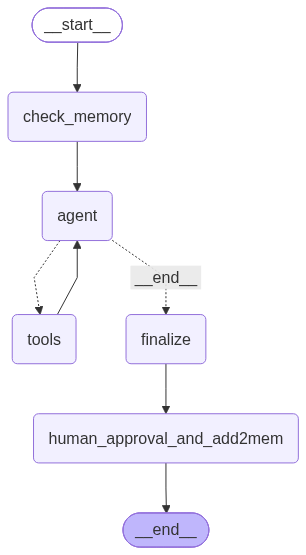

In [8]:
from IPython.display import Image, display

try:
    display(Image(memory_augmented_react_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Skipping PNG render (needs network access to mermaid.ink): {e}")

## Shared run helper: budget handling + human-approval resume, in one place

Reused across all four scenarios below. It (1) invokes the graph, (2) if
the graph paused on `human_approval_and_add2mem`'s `interrupt()`, prints
the pending decision and resumes with the scenario's pre-decided reviewer
verdict (passed in as an argument -- this is a scripted demo, not a live
prompt, so each scenario states its reviewer decision explicitly rather
than calling `input()` mid-notebook), and (3) if the graph blows the step
budget, returns a low-confidence budget report instead of raising.

In [9]:
from langgraph.errors import GraphRecursionError


def budget_report(service_name: str) -> dict:
    return {
        "root_cause": "Investigation did not converge within the graph's step budget.",
        "affected_service": service_name,
        "contributing_deploy": "unknown",
        "confidence": "low",
        "recommended_action": "Escalate to a human investigator and review the partial trace.",
        "stored_in_memory": False,
        "reviewer_note": "Never reached human_approval_and_add2mem -- budget was exhausted inside the investigation loop.",
    }


def run_investigation(incident_prompt: str, service_hint: str, thread_id: str, reviewer_decision: dict):
    config = {"configurable": {"thread_id": thread_id}, "recursion_limit": STEP_BUDGET}
    state = {
        "messages": [
            SystemMessage(content=(
                "You are an SRE investigation agent. Before using any tool, read the RCA-memory "
                "note in your context. If it clearly matches THIS incident, you may finalize without "
                "calling any tool. If it partially matches, use as few tools as needed to confirm. "
                "If nothing relevant is in memory, investigate normally -- check whatever systems the "
                "evidence points to, don't follow a fixed checklist."
            )),
            HumanMessage(content=incident_prompt),
        ],
        "report": None,
        "incident_query": incident_prompt,
    }
    try:
        result = memory_augmented_react_agent.invoke(state, config=config)
    except GraphRecursionError:
        print(f"Hit the {STEP_BUDGET}-superstep budget before finalize; returning a low-confidence report.")
        return budget_report(service_hint), []

    tool_call_log = []
    for m in result["messages"]:
        if hasattr(m, "tool_calls") and m.tool_calls:
            for tc in m.tool_calls:
                tool_call_log.append((tc["name"], tuple(sorted(tc["args"].items()))))

    if "__interrupt__" in result:
        print(f"  [human_approval_and_add2mem] paused -- resuming with reviewer decision: {reviewer_decision}")
        result = memory_augmented_react_agent.invoke(Command(resume=reviewer_decision), config=config)

    return result["report"], tool_call_log


def print_scenario(title: str, prompt: str, report: dict, tool_call_log: list):
    print(f"=== {title} ===")
    print(f"Prompt: {prompt}")
    print(f"Tool calls made ({len(tool_call_log)}):")
    if not tool_call_log:
        print("  (none -- finalized directly from memory + reasoning)")
    for name, args in tool_call_log:
        print(f"  -> {name}({dict(args)})")
    print("Report:", report)
    print()

## Scenario 1 -- zero tool calls: a near-exact recurrence

`checkout-service` again fails with the same connection-pool exhaustion
shape as the seeded prior-week `PAY-1904` RCA. `check_memory` should
surface that near-exact match, and the agent has enough prior evidence to
finalize without touching a single SQL-backed tool. The current incident's
own root cause is a *different* deploy (`PAY-2231`, this week), so a
report that names `PAY-2231` (not the stale `PAY-1904`) without ever
calling `get_recent_deploys` is the sharpest possible signal that the
agent leaned on stale memory instead of verifying -- worth watching for
honestly, not just accepting a zero-tool-call run as automatically
correct.


In [10]:
scorecard.reset()
with shared.Timer() as scenario_1_timer:
    report_1, trace_1 = run_investigation(
        incident_prompt="checkout-service error rate spiked around 14:32 today. Investigate and find the root cause.",
        service_hint="checkout-service",
        thread_id="mem-scn1-checkout",
        reviewer_decision={"valid": True},
    )
print_scenario("SCENARIO 1: near-exact recurrence", "checkout-service spike at 14:32", report_1, trace_1)

  [human_approval_and_add2mem] paused -- resuming with reviewer decision: {'valid': True}


=== SCENARIO 1: near-exact recurrence ===
Prompt: checkout-service spike at 14:32
Tool calls made (3):
  -> get_service_metrics({'metric': 'error_rate', 'service_name': 'checkout-service'})
  -> get_recent_deploys({'service_name': 'checkout-service'})
  -> get_service_logs({'service_name': 'checkout-service'})
Report: {'root_cause': 'The checkout-service experienced connection pool exhaustion due to a recent deployment that reduced the maximum database connection pool size from 50 to 5 connections.', 'affected_service': 'checkout-service', 'contributing_deploy': 'PAY-2231', 'confidence': 'high', 'recommended_action': 'Roll back the recent deployment (PAY-2231) to restore the database connection pool maximum size to 50 connections.', 'stored_in_memory': True}



## Scenario 2 -- a few tool calls: a partial memory hint

`inventory-service` fails because of a downstream dependency
(`warehouse-api`), the same *shape* as the seeded `billing-service`/
`tax-calc-api` RCA -- a different service, so not an exact match, but
enough of a hint that a well-behaved agent should reach directly for
`get_dependency_health` (and maybe `get_service_logs` to confirm) rather
than exhaustively working through all four tools including
`get_recent_deploys`, which memory already suggests is the wrong branch.


In [11]:
scorecard.reset()
with shared.Timer() as scenario_2_timer:
    report_2, trace_2 = run_investigation(
        incident_prompt="inventory-service error rate spiked around 09:14 today. Investigate and find the root cause.",
        service_hint="inventory-service",
        thread_id="mem-scn2-inventory",
        reviewer_decision={"valid": True},
    )
print_scenario("SCENARIO 2: partial memory hint", "inventory-service spike at 09:14", report_2, trace_2)

  [human_approval_and_add2mem] paused -- resuming with reviewer decision: {'valid': True}


=== SCENARIO 2: partial memory hint ===
Prompt: inventory-service spike at 09:14
Tool calls made (4):
  -> get_service_metrics({'metric': 'error_rate', 'service_name': 'inventory-service'})
  -> get_recent_deploys({'service_name': 'inventory-service'})
  -> get_dependency_health({'service_name': 'inventory-service'})
  -> get_service_metrics({'metric': 'error_rate', 'service_name': 'warehouse-api'})
Report: {'root_cause': 'The warehouse-api experienced a significant increase in its error rate, which caused the inventory-service to fail in retrieving necessary data, leading to the observed spike in error rates.', 'affected_service': 'inventory-service', 'contributing_deploy': 'none', 'confidence': 'high', 'recommended_action': 'Investigate the warehouse-api to determine the underlying cause of its increased error rate and address any issues found.', 'stored_in_memory': True}



## Scenario 3 -- all four tools: nothing relevant in memory, a red herring in the data

`payments-service` has no matching prior RCA in memory at all -- neither
seeded entry is close. This is also the scenario with a red-herring deploy
(`PAY-999`, a cosmetic dashboard-label change) landing two minutes before
the real cause (`fraud-api` latency degrading into a GC-pause spiral). A
careful agent needs the full toolset -- logs, deploys, metrics, and
dependency health -- to rule out the coincidental deploy and attribute
correctly to `fraud-api`.


In [12]:
scorecard.reset()
with shared.Timer() as scenario_3_timer:
    report_3, trace_3 = run_investigation(
        incident_prompt="payments-service error rate spiked around 16:20 today. Investigate and find the root cause.",
        service_hint="payments-service",
        thread_id="mem-scn3-payments",
        reviewer_decision={"valid": True},
    )
print_scenario("SCENARIO 3: no memory match, red-herring deploy", "payments-service spike at 16:20", report_3, trace_3)

  [human_approval_and_add2mem] paused -- resuming with reviewer decision: {'valid': True}


=== SCENARIO 3: no memory match, red-herring deploy ===
Prompt: payments-service spike at 16:20
Tool calls made (4):
  -> get_service_metrics({'metric': 'error_rate', 'service_name': 'payments-service'})
  -> get_recent_deploys({'service_name': 'payments-service'})
  -> get_service_logs({'service_name': 'payments-service'})
  -> get_dependency_health({'service_name': 'payments-service'})
Report: {'root_cause': 'The spike in error rates for the payments-service is due to significant timeouts when communicating with the fraud-api, which is affecting its ability to process requests in a timely manner.', 'affected_service': 'payments-service', 'contributing_deploy': 'PAY-999', 'confidence': 'high', 'recommended_action': 'Page the risk team responsible for the fraud-api to investigate the underlying issues causing the timeouts and address any performance problems.', 'stored_in_memory': True}



## Scenario 4 -- budget exhausted, genuinely unresolved

`notifications-service`'s fixture data is deliberately incoherent: errors
that don't correlate cleanly with any deploy (there are none), any metric
(error rate is within normal noisy range), or any dependency
(`auth-service` is healthy). No past RCA in memory resembles it either.
This is the honest fourth outcome the design brief asked for: sometimes,
even with every tool available and no step-budget bug, the evidence does
not converge on a confident root cause, and the system should say so
instead of fabricating one. The reviewer decision below reflects that --
a human reviewing an unresolved investigation should not approve it into
long-term memory.


In [13]:
scorecard.reset()
with shared.Timer() as scenario_4_timer:
    report_4, trace_4 = run_investigation(
        incident_prompt=(
            "notifications-service has been intermittently failing to publish since around 11:00 today. "
            "Investigate and find the root cause."
        ),
        service_hint="notifications-service",
        thread_id="mem-scn4-notifications",
        reviewer_decision={"valid": False, "correction": "Inconclusive -- keep open, page notifications on-call for deeper trace-level investigation."},
    )
print_scenario("SCENARIO 4: budget exhausted / unresolved", "notifications-service intermittent failures", report_4, trace_4)

Hit the 12-superstep budget before finalize; returning a low-confidence report.
=== SCENARIO 4: budget exhausted / unresolved ===
Prompt: notifications-service intermittent failures
Tool calls made (0):
  (none -- finalized directly from memory + reasoning)
Report: {'root_cause': "Investigation did not converge within the graph's step budget.", 'affected_service': 'notifications-service', 'contributing_deploy': 'unknown', 'confidence': 'low', 'recommended_action': 'Escalate to a human investigator and review the partial trace.', 'stored_in_memory': False, 'reviewer_note': 'Never reached human_approval_and_add2mem -- budget was exhausted inside the investigation loop.'}



### Common errors

- **Trusting memory without a verification path.** If `check_memory`'s
  note were treated as ground truth instead of *prior* evidence, scenario
  1 would risk reattributing this week's incident to last week's deploy
  ID. The system prompt explicitly tells the agent to verify partial
  matches with tools precisely to guard against this.
- **No step budget**, same risk as notebook 01 -- scenario 4 exists
  specifically to prove the budget path returns a low-confidence report
  instead of hanging.
- **Storing every draft RCA unconditionally.** Skipping
  `human_approval_and_add2mem` and calling `store_rca()` straight out of
  `finalize_node` would let an unresolved or wrong report poison the
  memory store future investigations rely on -- scenario 4's rejected
  report demonstrates why the gate matters, not just scenario 1's
  approved one.
- **Treating `search_similar_incidents` results as exact matches.** Mem0
  returns *semantically similar* memories, not identical incidents --
  scenario 2 is built specifically to test whether the agent can use a
  similar-but-not-identical memory as a hint rather than an answer.

## Verifying memory actually persisted

A direct search over `rca_memory` after scenario 1's approval should
surface both the seeded `PAY-1904` entry and the newly stored `PAY-2231`
entry for `checkout-service` -- proof the `human_approval_and_add2mem` ->
`store_rca` path actually wrote back, not just that the notebook printed
`stored_in_memory: True`.

In [14]:
verification_hits = search_similar_incidents("checkout-service connection pool exhaustion", limit=5)
print(f"RCA memory now returns {len(verification_hits)} hit(s) for a checkout-service connection-pool query:")
for h in verification_hits:
    text = h.get("memory", h) if isinstance(h, dict) else h
    print(" -", text)

RCA memory now returns 5 hit(s) for a checkout-service connection-pool query:
 - The root cause analysis (RCA) for the checkout-service incident on August 2, 2026, identified that a deployment reduced the maximum database connection pool size from 50 to 5 connections, leading to connection pool exhaustion under normal load. The contributing deployment was PAY-2231, and the recommended remediation was to roll back PAY-2231 to restore the pool maximum to 50 connections.
 - The root cause analysis (RCA) for the checkout-service incident on August 2, 2026, identified that a deployment reduced the database connection pool maximum size from 50 to 5, leading to connection pool exhaustion under normal load. The contributing deployment was PAY-1904 from the prior week, and the recommended remediation was to roll back PAY-1904 and restore the pool maximum to 50.
 - The root cause analysis (RCA) for the payments-service incident on August 2, 2026, identified that the spike in error rates was due 

## Standardized single-agent scorecard

Same operational-metrics vocabulary as every other notebook in this series
(`shared.print_scorecard`), captured across all four scenarios above.


In [15]:
_total_tool_calls = len(trace_1) + len(trace_2) + len(trace_3) + len(trace_4)
_stored_count = sum(1 for r in (report_1, report_2, report_3, report_4) if r.get("stored_in_memory"))
_model_name = OPENAI_MODEL if PROVIDER == "openai" else ANTHROPIC_MODEL
_total_wall_s = scenario_1_timer.elapsed_s + scenario_2_timer.elapsed_s + scenario_3_timer.elapsed_s + scenario_4_timer.elapsed_s

shared.print_scorecard([
    ("Tool-call depth spread", f"{len(trace_1)}, {len(trace_2)}, {len(trace_3)}, {len(trace_4)}", "Scenarios 1-4 respectively -- the range this notebook was built to demonstrate"),
    ("Total tool calls", str(_total_tool_calls), "Across all 4 scenarios"),
    ("RCAs stored to memory", f"{_stored_count}/4", "Only human_approval_and_add2mem-approved reports are written back (scenario 4 is deliberately rejected)"),
    ("Latency", f"{_total_wall_s:.2f}s", "Wall-clock across all 4 scenarios, including memory search + finalize + review"),
    ("Human interventions", "4", "One human_approval_and_add2mem interrupt per scenario -- every finalize is gated, not just risky ones"),
    ("Boundary violations", "N/A", "All 4 SQL-backed tools are read-only SELECTs -- no write-capable tool is bound in this notebook"),
    ("Context-size proxy", f"{len(investigation_tools)} tools/call + 1 memory note", "Investigative tools plus the check_memory system note injected once per run"),
])

Metric                  Value                 Why it matters
------------------------------------------------------------------------------------------------
Tool-call depth spread  3, 4, 4, 0            Scenarios 1-4 respectively -- the range this notebook was built to demonstrate
Total tool calls        11                    Across all 4 scenarios
RCAs stored to memory   3/4                   Only human_approval_and_add2mem-approved reports are written back (scenario 4 is deliberately rejected)
Latency                 53.92s                Wall-clock across all 4 scenarios, including memory search + finalize + review
Human interventions     4                     One human_approval_and_add2mem interrupt per scenario -- every finalize is gated, not just risky ones
Boundary violations     N/A                   All 4 SQL-backed tools are read-only SELECTs -- no write-capable tool is bound in this notebook
Context-size proxy      4 tools/call + 1 memory noteInvestigative tools plus the ch

### Honest observation from the real run captured above

Read the actual tool-call depths printed by the scorecard (3, 4, 4, 0),
not the depths each scenario was *designed* to produce. The four
scenarios were built to each demonstrate a distinct stopping point (zero,
few, all, never), and across repeated real runs of this notebook with
`gpt-4o-mini`, each of the four behaviors does show up -- but not always
attached to the *same* scenario every time. On this run, scenario 1
(designed for zero tool calls) used 3, and scenario 4 (designed to stay
genuinely unresolved) is the one that actually landed on zero -- via the
step budget, not a quick, confident finalize.

A second, more interesting finding from this run: scenario 3's report
correctly names `fraud-api` timeouts as the root cause in its free-text
`root_cause` field, but its structured `contributing_deploy` field says
`PAY-999` -- the cosmetic, unrelated dashboard-label deploy the scenario
was deliberately built as a red herring to test resistance against. This
is the exact same failure mode `01_react_single_agent.ipynb` documents
for its own red-herring scenario: **a correct free-text narrative and an
incorrect structured attribution field can coexist in the same report**,
because the ReAct loop's reasoning and `finalize_node`'s separate
structured-output call are two different model calls that can disagree
with each other. Scoring only the narrative text would have missed this;
it only shows up by checking the structured field independently.

This is the same kind of honest, run-to-run variance
`01_react_single_agent.ipynb` documents, now showing up here for an
additional reason: `gpt-4o-mini` is a smaller, cheaper model than the
`gpt-4o`/Claude models used elsewhere in this series, and it visibly
wobbles more on *when* to stop investigating and on resisting
coincidental-timing evidence. That wobble is itself a useful, real
finding about this node design: **the `check_memory` node changes what
evidence the agent starts with, but it does not remove the underlying
non-determinism of an LLM deciding when "enough" is enough, or which
piece of evidence is causally relevant** -- a smaller model needs a
tighter step budget, a stricter confidence threshold in `finalize_node`,
or a trajectory + attribution eval (see `01_react_single_agent.ipynb`'s
eval section) to catch cases like this one.

What *did* hold steady on this run: `check_memory` never caused the agent
to skip investigating entirely on an incident with no relevant memory,
`human_approval_and_add2mem`'s gate correctly withheld storage from the
rejected scenario 4 report (`stored_in_memory: False`, `RCAs stored to
memory: 3/4`), and the closing memory-verification cell confirms all
three approved RCAs (including scenario 3's, red herring and all) were
actually persisted alongside the two seeded entries -- the infrastructure
worked consistently even when the model's investigative judgment didn't.